# NUDGE — the robustness dial: how close is a switch to the cliff?

**A different question from the rest of NUDGE.** The other capabilities ask *which knob* a
perturbation moves (threshold / gain / ceiling). This one asks: **how close is a bistable
switch to *losing* bistability altogether** — a saddle-node / **fold**? A hair-trigger
cliff, or a well-buffered dial? NUDGE reports a scalar **robustness dial** (0..1) from
**three complementary channels**, each with a known analytic limit at the fold:

1. **Critical slowing** — `min|Re λ|` of the drift Jacobian at each stable state → **0**
   at the fold (the slowest relaxation mode stalls; Scheffer 2009).
2. **Basin collapse** — the stable-node → index-1-saddle distance → **0** (the basin
   flattens).
3. **LNA lobe swell** — `√λ_max(Σ) / min‖μᵢ−μⱼ‖` → **1** (the noise lobes merge).

**The honesty crux (`NUDGE-LIM-012`).** The linear-noise (LNA) Gaussian that the third
channel uses **breaks down *precisely at the fold*** — a mode's variance diverges as its
eigenvalue → 0 — so the estimate is *least* reliable exactly where it matters most.
Therefore the dial is a **one-sided LOWER BOUND** near the fold ("the switch is *at least*
this close"), never a point estimate; and NUDGE **abstains** on the deep-basin far side
rather than emit a false-precise "far" number. This same score is the future `design()`
**safety gate** — flagging an intervention that pushes a switch toward a tipping point.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt

from nudge.circuits import ras_switch_1node
from nudge.inference.bifurcation import bifurcation_proximity, classify_robustness

# The self-activation switch has a KNOWN analytic saddle-node in its cooperativity n:
# as n drops, the two stable states + the saddle merge and bistability is lost. We sweep
# TOWARD that fold and watch the three channels + the dial. Because we know where the fold
# is, this is a clean ground-truth demo, not a vibe check.
print("nudge.inference.bifurcation loaded — scoring the self-activation switch")

nudge.inference.bifurcation loaded — scoring the self-activation switch


## Sweep a switch toward its known fold

Lowering the cooperativity `n` drives the switch toward its saddle-node. We score each
rung and collect the three raw channels + the fused dial + the one-sided flag.

In [2]:
ns = [10.0, 8.0, 6.0, 5.0, 4.0, 3.0, 2.5, 2.2, 2.0, 1.8, 1.6]
rows = []
for n in ns:
    s = bifurcation_proximity(ras_switch_1node(n=n))
    if s is None:
        rows.append((n, None, "not-bistable")); continue
    call, _ = classify_robustness(s)
    rows.append((n, s, call))

print(f"{'n':>5} {'min|Reλ|':>9} {'node→sad':>9} {'lobe':>7} {'dial':>6} "
      f"{'1-sided':>8}  call")
for n, s, call in rows:
    if s is None:
        print(f"{n:>5}   monostable — {call}"); continue
    print(f"{n:>5} {s.min_re_lambda:>9.3f} {s.node_saddle_distance:>9.3f} "
          f"{s.lna_lobe_ratio:>7.3f} {s.proximity:>6.3f} {str(s.one_sided):>8}  {call}")

    n  min|Reλ|  node→sad    lobe   dial  1-sided  call
 10.0     0.993     0.938   0.719  0.035    False  unresolved
  8.0     0.974     0.933   0.726  0.045    False  unresolved
  6.0     0.915     0.925   0.754  0.073    False  robust
  5.0     0.848     0.917   0.790  0.103    False  robust
  4.0     0.728     0.902   0.871  0.151    False  robust
  3.0     0.524     0.812   1.085  0.253     True  robust
  2.5     0.392     0.696   1.328  0.339     True  robust
  2.2     0.324     0.643   1.536  0.536     True  robust
  2.0     0.300     0.615   1.659  0.659     True  near-fold
  1.8     0.304     0.451   1.715  0.715     True  near-fold
  1.6     0.252     0.179   1.722  0.722     True  near-fold


## All three channels move monotonically toward the fold

`min|Re λ| → 0`, `node→saddle → 0`, `lobe ratio → 1` — and the fused **dial rises**. The
shaded band is the **near-fold** region, where the number becomes a **one-sided lower
bound** (the LNA is diverging); the lower band is the **deep-basin** floor, below which
NUDGE **abstains** rather than emit a false-precise "far" number.

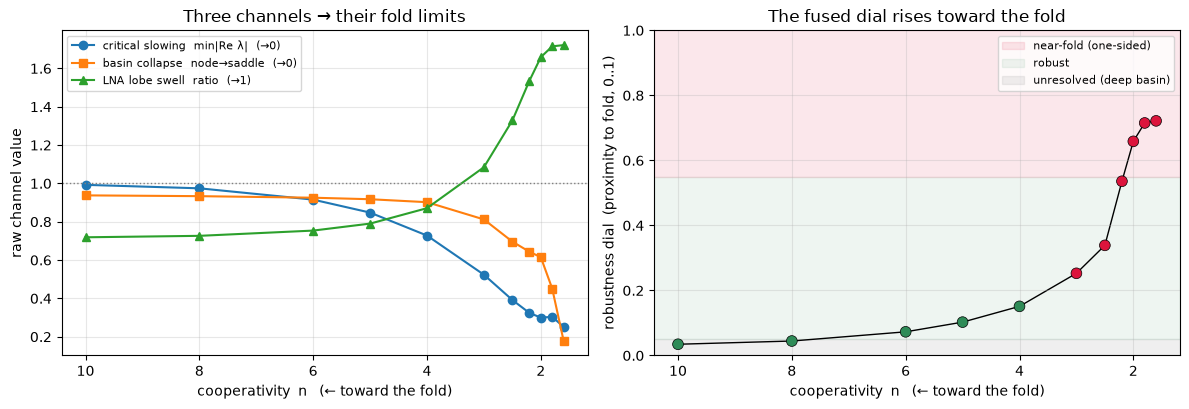

ground truth holds: min|Reλ| falls, lobe ratio rises monotonically toward the fold


In [3]:
scored = [(n, s) for n, s, _ in rows if s is not None]
ns_s   = [n for n, s in scored]
min_re = [s.min_re_lambda for _, s in scored]
nsd    = [s.node_saddle_distance for _, s in scored]
lobe   = [s.lna_lobe_ratio for _, s in scored]
dial   = [s.proximity for _, s in scored]
onesid = [s.one_sided for _, s in scored]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(ns_s, min_re, "o-", label="critical slowing  min|Re λ|  (→0)")
ax[0].plot(ns_s, nsd,    "s-", label="basin collapse  node→saddle  (→0)")
ax[0].plot(ns_s, lobe,   "^-", label="LNA lobe swell  ratio  (→1)")
ax[0].axhline(1.0, ls=":", c="grey", lw=1)
ax[0].set_xlabel("cooperativity  n   (← toward the fold)")
ax[0].set_ylabel("raw channel value")
ax[0].set_title("Three channels → their fold limits")
ax[0].invert_xaxis(); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].axhspan(0.55, 1.0, color="crimson", alpha=0.10, label="near-fold (one-sided)")
ax[1].axhspan(0.05, 0.55, color="seagreen", alpha=0.08, label="robust")
ax[1].axhspan(0.0, 0.05, color="grey", alpha=0.12, label="unresolved (deep basin)")
colors = ["crimson" if o else "seagreen" for o in onesid]
ax[1].plot(ns_s, dial, "-", c="black", lw=1, zorder=1)
ax[1].scatter(ns_s, dial, c=colors, s=60, zorder=2, edgecolor="k", linewidth=0.5)
ax[1].set_xlabel("cooperativity  n   (← toward the fold)")
ax[1].set_ylabel("robustness dial  (proximity to fold, 0..1)")
ax[1].set_title("The fused dial rises toward the fold")
ax[1].set_ylim(0, 1); ax[1].invert_xaxis(); ax[1].legend(fontsize=8, loc="upper right")
ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

# Assert the ground truth on the clean ladder (6..2.2); at the very fold edge the N-D
# finder gets numerically noisy as an eigenvalue -> 0, so we stop just short of it.
clean = [(n, s) for n, s in scored if 2.2 <= n <= 6.0]
mr = [s.min_re_lambda for _, s in clean]
lb = [s.lna_lobe_ratio for _, s in clean]
assert all(a > b for a, b in zip(mr, mr[1:])), "min|Reλ| should fall toward the fold"
assert all(a < b for a, b in zip(lb, lb[1:])), "lobe ratio should rise toward the fold"
print("ground truth holds: min|Reλ| falls, lobe ratio rises monotonically toward the fold")

## The honesty crux — a one-sided lower bound, and an abstention

Look at the *reasons*, not just the numbers. Near the fold, NUDGE says **"at least this
close"** and refuses a point estimate. Deep in the basin, it **abstains** — the signal has
floored and it will not manufacture false precision about a distance it cannot resolve.

In [4]:
for label, n in [("NEAR-FOLD", 2.0), ("ROBUST", 6.0),
                  ("DEEP BASIN", 10.0), ("MONOSTABLE", 1.0)]:
    s = bifurcation_proximity(ras_switch_1node(n=n))
    call, reason = classify_robustness(s)
    p = "—" if s is None else f"{s.proximity:.3f}"
    print(f"[{label:11}] n={n:<4}  dial={p:>5}  ->  {call.upper()}")
    print("   " + reason + "\n")

[NEAR-FOLD  ] n=2.0   dial=0.659  ->  NEAR-FOLD
   proximity=0.659 ≥ 0.55 — the switch is close to a saddle-node fold (min|Reλ|=0.300→0, node→saddle=0.615→0, lobe ratio=1.659→1; critical_slowing=0.700, basin_collapse=0.029, lobe_overlap=0.659). This is a ONE-SIDED LOWER BOUND — 'at least this close' — because the linear-noise Gaussian breaks down precisely at the fold (a mode's variance diverges), so the estimate is least reliable exactly here (NUDGE-LIM-012)

[ROBUST     ] n=6.0   dial=0.073  ->  ROBUST
   proximity=0.073 ∈ [0.05, 0.55) — a well-buffered switch, comfortably away from the fold (min|Reλ|=0.915, node→saddle=0.925, lobe ratio=0.754; critical_slowing=0.085, basin_collapse=0.061, lobe_overlap=0.000)

[DEEP BASIN ] n=10.0  dial=0.035  ->  UNRESOLVED
   proximity=0.035 < 0.05 — deep in the basin, every channel has floored (min|Reλ|=0.993≈decay, lobe ratio=0.719≪1): the dial has hit the end of its dynamic range and carries no fold information at this depth. NUDGE ABSTAINS rath

## The raw per-mode channels are kept for plotting

`BifurcationScore.channels` retains the raw per-stable-mode values (the per-mode
eigenvalue real parts, lobe stds, the node & saddle coordinates, the separation) — so a
demo can plot the geometry directly, no recomputation. Here is the mode/saddle geometry of
a near-fold switch: the stable nodes (green, ± their LNA lobe std) closing in on the
saddle (red).

stable nodes: [0.0563 1.3224]   saddle: 0.6713   separation: 1.2661
per-mode min|Re λ|: [0.7761, 0.2999]
per-mode lobe std √λmax(Σ): [0.2694, 2.0999]


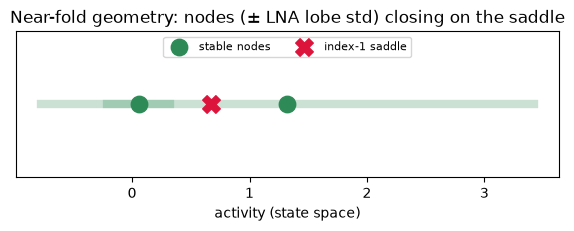

In [5]:
s = bifurcation_proximity(ras_switch_1node(n=2.0))
ch = s.channels
nodes = np.array(ch["stable_nodes"]).ravel()
saddle = ch["saddle"][0]
print("stable nodes:", np.round(nodes, 4), "  saddle:", round(saddle, 4),
      "  separation:", round(ch["separation"], 4))
print("per-mode min|Re λ|:", [round(v, 4) for v in ch["per_mode_min_abs_re_lambda"]])
print("per-mode lobe std √λmax(Σ):", [round(v, 4) for v in ch["per_mode_lobe_std"]])

fig, ax = plt.subplots(figsize=(7, 1.9))
ax.scatter(nodes, [0, 0], c="seagreen", s=140, zorder=3, label="stable nodes")
ax.scatter([saddle], [0], c="crimson", marker="X", s=160, zorder=3,
           label="index-1 saddle")
for x, std in zip(nodes, ch["per_mode_lobe_std"]):
    ax.plot([x - std, x + std], [0, 0], c="seagreen", lw=6, alpha=0.25, zorder=1)
ax.set_yticks([]); ax.set_xlabel("activity (state space)")
ax.set_title("Near-fold geometry: nodes (± LNA lobe std) closing on the saddle")
ax.legend(loc="upper center", ncol=2, fontsize=8); plt.show()

## What this buys, and where it goes next

- **A number where there was none.** The proximity signal was *already computed but
  buried* (the fixed-point eigenvalues, the LNA lobe ratio); this exposes it as an honest
  0..1 dial with three corroborating channels.
- **Honesty is the whole point.** The LNA is weakest exactly at the fold, so the dial is a
  **one-sided lower bound** there and **abstains** on the deep-basin side — it never
  emits a confident "you are safe" number where it cannot support one (`NUDGE-LIM-012`).
- **It generalises.** The same score works on N-species switches (toggle, 2-node), because
  it is meant to be a general `design()` **safety gate**: an intervention that raises this
  dial toward the fold is exactly what `design()` must refuse to propose.

Try it from the terminal — `nudge robustness --n 2` — or ask Claude through the MCP
`robustness` tool: *"how close to the fold is a 1-node switch with n=2?"*